# Excluding Pseudomonas

This data contains all of the data _except_ anything related to the family Pseudomonadaceae. We filted all reads that map to Pseudomonadaceae before calculating the subsystems and before summarising the taxonomy. There is only one column missing, that is `f__Pseudomonadaceae` from the taxonomy, because each of the other columns have entries that belong to `p__Pseudomonodata` but not `f__Pseudomonadaceae`.

We are going to rebuild the auto-encoder and run the Pseudomonas analysis, taken directly from `AutoEncoding.ipynb` and `Pseudomonas_predictions.ipynb`, with little description!

In [1]:
import os
import sys

import torch

import tensorflow as tf
from tensorflow.keras import layers, models

# we don't use pytorch below, but this is a convenient way to ensure we have a GPU-enabled system
if not (torch.cuda.is_available() or torch.xpu.is_available()):
    print("FATAL: Please run this notebook in an environment with CUDA available", file=sys.stderr)
else:
    print("Lets go GPU", file=sys.stderr)

from socket import gethostname
hostname = gethostname()

if hostname.startswith('hpc-node'):
    IN_DEEPTHOUGHT = True
    sys.path.append('..')
else:
    IN_DEEPTHOUGHT = False
from cf_analysis_lib.load_libraries import *
import cf_analysis_lib


2026-04-21 22:07:27.467831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776775047.488792 2281489 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776775047.495839 2281489 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776775047.511788 2281489 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776775047.511822 2281489 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776775047.511825 2281489 computation_placer.cc:177] computation placer alr

In [2]:
sequence_type = "MGI"
datadir = '..'
sslevel = 'subsystems_norm_ss.tsv.gz'
taxa = "family"

In [3]:
selection = 'MGI_no_pseudomonas'
df, metadata = cf_analysis_lib.read_selected_data(sequence_type, datadir, selection=selection, sslevel='subsystems_norm_ss.tsv.gz', taxa="family")
df.shape

(127, 1511)

# Build the model 

The next set of cells are taken directly from AutoEncoding.ipynb, and are merged to just run in one cell.

Please check that notebook for detailed instructions and comments.

In [4]:
# somewhere to save things
outdir = 'cluster_gbrfs_no_pseudomonas'
os.makedirs(outdir, exist_ok=True)

# split the data
training_data, validate_data = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train: {training_data.shape}")
print(f"Test: {validate_data.shape}")

Train: (101, 1511)
Test: (26, 1511)


I0000 00:00:1776775059.899117 2281489 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100-PCIE-32GB, pci bus id: 0000:41:00.0, compute capability: 7.0


Epoch 1/200


I0000 00:00:1776775064.481619 2281516 service.cc:152] XLA service 0x155308010640 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776775064.481652 2281516 service.cc:160]   StreamExecutor device (0): Tesla V100-PCIE-32GB, Compute Capability 7.0
2026-04-21 22:07:44.585165: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776775064.885443 2281516 cuda_dnn.cc:529] Loaded cuDNN version 91900


1/7 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - loss: 106945400.0000

I0000 00:00:1776775066.364609 2281516 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 377ms/step - loss: 98127408.0000 - val_loss: 88366280.0000
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 66269412.0000 - val_loss: 44222676.0000
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 43263140.0000 - val_loss: 37907516.0000
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 37996976.0000 - val_loss: 34320336.0000
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 35237432.0000 - val_loss: 30639798.0000
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 31633614.0000 - val_loss: 25517476.0000
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 26412386.0000 - val_loss: 18758110.0000
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 21531080.0000 - val_loss: 13306858.0000
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 18235858.0000 - val_loss: 11069460.0000
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 16156533.0000 - val_loss: 9017357.0000
Epoch 11/200
7/7 ━━━━━━━━━━━━━━

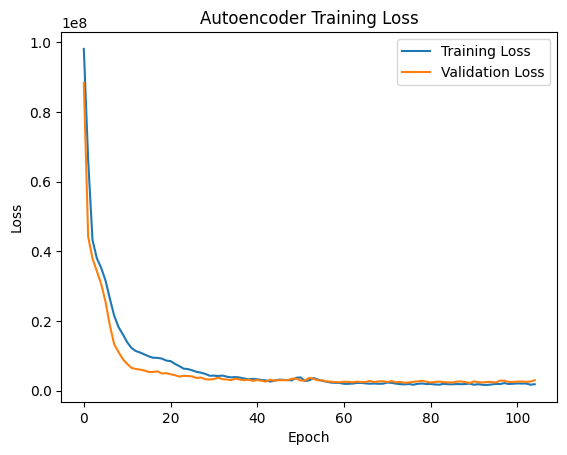

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [5]:
# Create and train the autoencoder

if os.path.exists(os.path.join(outdir, "autoencoder_model.keras")):
    print(f"Loading the autoencoder from disk. Remove {os.path.join(outdir, 'autoencoder_model.keras')} to recreate the model", file=sys.stderr)
    autoencoder = models.load_model(os.path.join(outdir, "autoencoder_model.keras"), compile=False)
    autoencoder.compile(optimizer='adam', loss='mse')
    encoder = models.load_model(os.path.join(outdir, "encoder_model.keras"), compile=False)
    decoder = models.load_model(os.path.join(outdir, "decoder_model.keras"), compile=False)
    encoder.compile()
    decoder.compile()
else:
    # 1) Define network parameters
    input_dim = len(df.columns)
    latent_dim = 50  # tweak this
    
    # 2) Build the encoder
    encoder_input = tf.keras.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(encoder_input)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    encoder_output = layers.Dense(latent_dim, activation='linear')(x)
    
    # 3) Build the decoder
    decoder_input = layers.Input(shape=(latent_dim,))
    y = layers.Dense(128, activation='relu')(decoder_input)
    y = layers.Dense(512, activation='relu')(y)
    decoder_output = layers.Dense(input_dim, activation='linear')(y)
    
    # 4) Create autoencoder
    encoder = tf.keras.Model(encoder_input, encoder_output, name="encoder")
    decoder = tf.keras.Model(decoder_input, decoder_output, name="decoder")
    
    autoencoder_input = tf.keras.Input(shape=(input_dim,))
    encoded = encoder(autoencoder_input)
    decoded = decoder(encoded)
    
    autoencoder = tf.keras.Model(autoencoder_input, decoded, name="autoencoder")
    
    # 5) Compile & train
    autoencoder.compile(optimizer='adam', loss='mse')
    result = autoencoder.fit(
        x=training_data,
        y=training_data,
        epochs=200,
        batch_size=16,
        validation_data=(validate_data, validate_data),
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)]
    )


    autoencoder.save(os.path.join(outdir, "autoencoder_model.keras"), overwrite=True)
    encoder.save(os.path.join(outdir, "encoder_model.keras"), overwrite=True)
    decoder.save(os.path.join(outdir, "decoder_model.keras"), overwrite=True)

    # Plot training & validation loss
    plt.plot(result.history['loss'], label='Training Loss')
    plt.plot(result.history['val_loss'], label='Validation Loss')
    
    plt.title('Autoencoder Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
    
# 6) Extract low-dimensional features
train_latent = encoder.predict(training_data)
val_latent = encoder.predict(validate_data)
latent_dimensions = encoder.predict(df)

In [6]:
# predict which features cluster

num_features = df.shape[1]  # 1512
num_latent_dims = latent_dimensions.shape[1]       # 50 - the number of output layers

corr_matrix = pd.DataFrame(index=df.columns, columns=[f"LD_{i}" for i in range(num_latent_dims)])

for i in range(num_features):
    for j in range(num_latent_dims):
        try:
            corr = np.corrcoef(df.iloc[:, i], latent_dimensions[:, j])[0, 1]
            corr_matrix.iloc[i, j] = corr
        except:
            print(f"Error predicting {i} and {j}", file=sys.stderr)
            break

corr_matrix = corr_matrix.astype(float)
corr_matrix.head()

,LD_0,LD_1,LD_2,LD_3,LD_4,LD_5,LD_6,LD_7,LD_8,LD_9,...,LD_40,LD_41,LD_42,LD_43,LD_44,LD_45,LD_46,LD_47,LD_48,LD_49
"2,3-diacetamido-2,3-dideoxy-d-mannuronic acid",-0.165805,0.009907,-0.099705,-0.249662,-0.194637,-0.165550,0.100963,-0.091067,-0.025818,0.253818,...,-0.007062,-0.333182,0.031292,-0.017325,0.350924,-0.099623,-0.033851,0.326925,0.296888,0.201667
2-O-alpha-mannosyl-D-glycerate utilization,0.404740,-0.445031,0.654226,0.416361,0.576967,0.541634,-0.648522,0.358676,0.640042,-0.023756,...,0.383708,0.358828,0.366530,-0.326808,-0.155472,-0.137901,0.401911,-0.521659,-0.416106,-0.554354
2-aminophenol Metabolism,-0.025195,-0.125302,0.118235,-0.154962,-0.145115,-0.025520,-0.100596,0.168661,0.170379,0.267610,...,0.073495,-0.298853,0.320426,0.019103,0.176733,-0.216218,0.364852,-0.094950,0.104026,0.007880
2-ketoacid oxidoreductases disambiguation,-0.226923,0.121663,-0.194832,-0.763857,-0.444484,-0.417175,0.053783,-0.478279,-0.310267,0.494779,...,0.089393,-0.452348,-0.009094,0.323837,0.848166,0.174492,-0.168095,0.427134,0.576881,0.615497
2-oxoglutarate dehydrogenase,-0.102050,0.291488,-0.538789,-0.264879,-0.529418,-0.406256,0.429788,-0.024792,-0.416868,0.206857,...,-0.170224,-0.337220,0.133786,0.397940,-0.017134,-0.212631,-0.077745,-0.022707,0.356289,0.483036


In [7]:
# cluster the original data and write those clusters

if os.path.exists(os.path.join(outdir, 'clusters.json')):
    with open(os.path.join(outdir, 'clusters.json'), 'r') as file:
        data = json.load(file)
    tmpjsondf = pd.DataFrame(list(data.items()), columns=['COPF', 'Feature'])
    cluster_assignments = tmpjsondf.explode('Feature').reset_index(drop=True)
    cluster_assignments['COPF'] = cluster_assignments['COPF'].astype(int)
else:
    # Calculate linkage on the rows (i.e., the features)
    Z = linkage(corr_matrix, method='ward', metric='euclidean')
    
    k = 150  # more clusters, smaller groups!
    clusters = fcluster(Z, k, criterion='maxclust')  # Each feature gets a cluster ID [1..k]
    
    # create a df with the cluster assignments
    cluster_assignments = pd.DataFrame({
        "Feature": corr_matrix.index,  # the feature names
        "COPF": clusters
    })
    cluster_assignments.sort_values("COPF", inplace=True)
    grouped = cluster_assignments.groupby("COPF")
    by_cluster = {str(cluster_id): group["Feature"].tolist() for cluster_id, group in grouped}
    with open(os.path.join(outdir, 'clusters.json'), 'w') as json_file:
        json.dump(by_cluster, json_file, indent=4)

# write the clusters out 
grouped = cluster_assignments.groupby("COPF")
with open(os.path.join(outdir, 'cluster_features.txt'), 'w') as out:
    for cluster_id, group in grouped:
        print(f"--- COPF {cluster_id} : Length {group['Feature'].shape[0]} ---", file=out)
        print(group["Feature"].tolist(), file=out)
        print(file=out)
cluster_assignments.to_csv(os.path.join(outdir, 'clusters.tsv'), sep="\t", index=False)

In [8]:
# out of curiosity, does anything have Pseudomonas left? It should not

interesting_cluster = None
interesting_cluster_count = 0
grouped = cluster_assignments.groupby("COPF")
for cluster_id, group in grouped:
    if group['Feature'].str.contains('Pseudomonas').any():
        if group['Feature'].str.contains('Pseudomonas').sum() > interesting_cluster_count:
            interesting_cluster_count = group['Feature'].str.contains('Pseudomonas').sum()
            interesting_cluster = cluster_id
        print(f"--- COPF {cluster_id} : Length {group['Feature'].shape[0]} ---")
        print(group["Feature"].tolist())
        print()

--- COPF 118 : Length 6 ---
['Maintenance of outer membrane lipid asymmetry', 'Alcanivoracaceae', 'Selenocysteine metabolism', 'Tripartite multidrug efflux systems (of RND type) in Pseudomonas', 'Lipopolysaccharide in K12', 'Zoogloeaceae']

--- COPF 123 : Length 50 ---
['Acyclic terpene utilization', 'Adenylylsulfate reductase', 'Geothermobacteraceae', 'ABC-type iron transport system', 'Potential DNA repair cluster', 'Quorum sensing regulation in Pseudomonas', 'CMP-pseudaminic acid synthesis', 'Cytochrome c oxidase EC 1.9.3.1', 'Dihydropyrimidine dehydrogenase', 'Cholera toxin', 'Carbon storage regulator', 'Biogenesis of cbb3-type cytochrome c oxidases', 'Extracellular matrix proteins (PSL) involved in mannose-rich biofilm formation in Pseudomonas', 'Beta-lactamases Ambler class D', 'Extracellular matrix proteins (PEL) involved in glucose-rich biofilm formation in Pseudomonas', 'Colwelliaceae', 'Bruguierivoracaceae', 'Heme and heme d1 biosynthesis from siroheme', 'Microbulbiferaceae', 

In [9]:
# Create a new df with the principle components of the data

if os.path.exists(os.path.join(outdir, 'pc_df.tsv')):
    pc_df = pd.read_csv(os.path.join(outdir, 'pc_df.tsv'), sep="\t", index_col=0)
else:
    pca = PCA(n_components=1)
    pc_df = pd.DataFrame(index=df.index, columns=[f"COPF {x+1}" for x in range(len(cluster_assignments.groupby("COPF").size()))])
    for cluster_id, group in grouped:
        df_clust = df[cluster_assignments.loc[cluster_assignments["COPF"] == cluster_id, "Feature"]]
        pc_df[f"COPF {cluster_id}"] = pca.fit_transform(df_clust).ravel()
    pc_df.to_csv(os.path.join(outdir, 'pc_df.tsv'), sep="\t")
pc_df

,COPF 1,COPF 2,COPF 3,COPF 4,COPF 5,COPF 6,COPF 7,COPF 8,COPF 9,COPF 10,...,COPF 141,COPF 142,COPF 143,COPF 144,COPF 145,COPF 146,COPF 147,COPF 148,COPF 149,COPF 150
1068841_20180306_S,205.981861,375.507124,1556.379855,417.075586,1547.408194,1306.642831,1716.058744,2120.843514,1903.140224,97582.746601,...,-5855.849898,-13904.024309,-273.030572,-104.651019,-968.482831,-267.525205,-545.178569,-216.653981,-606.392757,-440.502757
1085876_20180227_S,351.102453,1916.516331,1941.686261,24.285469,1709.734266,1377.551837,40.978114,2025.872457,162.252161,45533.048453,...,-5847.381537,-51291.512723,3219.109271,-69.351866,-285.328573,-248.081148,-161.853420,-401.788489,-1145.904594,-368.565213
1128691_20171206_S,-3663.023054,-3331.660058,-4413.504466,-2748.008401,-5680.135597,-4114.825139,-7071.694372,-9128.131270,-6053.485403,-195344.099641,...,-12435.650565,-50717.333150,-616.446207,-1065.985243,4354.216169,-580.001321,-34.434174,-523.349271,1908.415338,2282.744585
1128691_20171218_S,-2558.056296,-2486.488780,-3626.266683,-1411.302903,-4340.324025,-3552.102319,-6011.995662,-7001.154098,-5401.049255,-173483.363960,...,-8565.501010,-36017.314423,-582.787719,-859.462968,3384.791463,-196.580946,157.856800,-386.850601,1194.219418,1983.228637
1128691_20180116_S,-3923.802568,-3755.163690,-5081.529874,-3333.584854,-6439.763349,-4681.975688,-7206.629662,-11300.328793,-6751.417596,-215978.315714,...,-8238.820712,-38382.734513,-570.990736,-923.205950,5442.287355,-287.264058,222.386572,-464.577980,2262.462591,2597.245633
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895293_20180502_S,1892.222830,-424.671504,-743.852341,-386.838259,2858.387881,-685.713069,-1009.735083,-571.688243,-1636.930437,90354.391443,...,-1111.806624,1427.212995,-218.573236,-175.580882,-660.937112,-152.261378,-184.143336,-13.582223,703.197298,746.372618
896213_20180427_S,386.292248,-589.991375,-1421.615416,-1016.252380,271.309209,-952.290610,4217.210015,-2715.868918,-771.807353,-42553.164362,...,-10611.415663,-55255.777768,-132.296989,-117.919514,-1457.608950,-906.643078,693.449442,-431.570488,-187.802447,-554.192922
913873_20180417_S,-160.910261,-831.568276,-48.309398,-277.789233,1452.865751,-218.900421,5117.298624,1424.300059,2040.478858,-1809.356429,...,-9507.938233,-54073.575063,-385.950625,-459.945701,-1345.552225,-582.832218,236.737845,-239.309449,-1198.579953,-1259.632028
980574_20180403_S,-414.483207,87.843381,-53.492614,-109.104761,1764.392705,-515.548510,-2770.651446,-246.651232,-265.998241,-2488.568477,...,1685.130210,14007.616055,-362.569770,-178.912767,-402.128468,-218.906573,-251.268706,300.982950,341.366862,-61.070566


In [26]:
# run the GBRF for every sample

# this is a complete hack, and I need to fix the code. If you delete this line you get an error!
cluster_assignments['Cluster'] = cluster_assignments['COPF']

# ignore adjustText warnings in this block
warnings.filterwarnings("ignore", category=UserWarning, module='adjustText')

replace_index = re.compile(r'^\d+\s+')
replace_nonword = re.compile(r'\W+')

resultsfile = open(os.path.join(outdir, 'gbrf_results.txt'), 'w')
print(f"Predictor\tFeature\tImportance", file=resultsfile)

skip_columns = {'MinION', 'PromethION', 'MGI', 'pwCF_ID', 'Sample_Type', 'Corr', 'CF gene 1', 'CS_NTM_(Smear negative)', 'CS_Aspergillus niger', 'CS_Aspergillus terreus',
                'CS_Scedosporium apiospermum', 'O_Scedosporium apiospermum', 'O_Trichosporon mycotoxinivorans', '3 Aztreonam_IV',
                'DNA_extraction_ conc', 'SAGC ULN', 'DNA Conc. (ng/ul)',
                'Index I7', 'Index I5', 'Mean_Size_BP', 'Total COPFs Passing Filter (Million)'}

n_estimators=1000

# make the image directories
os.makedirs(os.path.join(outdir, "img", "clusters"), exist_ok=True)

shouldskip = []
doskip = False
for intcol in metadata.columns:
    if intcol == 'XXXXX': # replace this if you want to restart part way through!
        doskip = False
    if doskip:
        continue
    if intcol in skip_columns:
        continue
    print(f"Working on {intcol}", file=sys.stderr)

    # set up our titles and the filename
    intcol_title = replace_index.sub('', intcol)
    intcol_filename = intcol.replace(" ", "_")
    intcol_filename = replace_nonword.sub('', intcol_filename)

    merged_df = pc_df.join(metadata[[intcol]]).dropna(subset=intcol)

    # do we need to encode this column
    custom_labels = {0: 'No', 1: 'Yes'}
    categorical_data = False
    if pd.api.types.is_numeric_dtype(metadata[intcol]):
        # this is an numeric column, so we can just continue
        categorical_data = False
    elif isinstance(metadata[intcol].dtype, pd.CategoricalDtype) and pd.api.types.is_numeric_dtype(metadata[intcol].cat.categories.dtype):
        # this is a categorical column with numeric categories so we can also continue
        categorical_data = True
    elif isinstance(merged_df[intcol].dtype, pd.CategoricalDtype):
        # this is a categorical column with string categories so we need to encode it
        print(f"Encoding string categories for {intcol}", file=sys.stderr)
        enc = OrdinalEncoder()
        metadata_encoder = enc.fit(merged_df[[intcol]])
        categories = list(metadata_encoder.categories_[0])
        
        merged_df[intcol] = metadata_encoder.transform(merged_df[[intcol]]).ravel().astype(int)
        
        # make it a pandas categorical using the original labels
        merged_df[intcol] = pd.Categorical.from_codes(
            merged_df[intcol],
            categories=categories
        )
        custom_labels = {code: cat for code, cat in enumerate(categories)}
        
        categorical_data = True
    else:
        # not sure what this is, so we skip it for now
        print(f"Error: {intcol} is not a numeric or categorical column. Skipped", file=sys.stderr)
        continue

    X = merged_df.drop(intcol, axis=1)
    y = merged_df[intcol]


    met = None

    if categorical_data or metadata[intcol].dtype == 'object':
        try:
            mse, feature_importances_sorted = cf_analysis_lib.gb_classifier(X, y, n_estimators)
            met = 'classifier'
        except ValueError as e:
            shouldskip.append(intcol)
            continue
    else:
        try:
            mse, feature_importances_sorted = cf_analysis_lib.gb_regressor(X, y, n_estimators)
            met = 'regressor'
        except ValueError as e:
            shouldskip.append(intcol)
            continue

    print(f"Mean squared error for {intcol} using {met} is {mse}", file=resultsfile)
    
    print(f"Features appearing at least once", file=resultsfile)
    for x in feature_importances_sorted.index[:20]:
        print(f"{intcol}\t{x}\t{feature_importances_sorted.loc[x, 'importance']}", file=resultsfile)
    print(file=resultsfile)
        
    y_features = 3

    topN = list(feature_importances_sorted[:y_features].index) + [intcol]
    fig, axes = plt.subplots(figsize=(10, 6), nrows=1, ncols=2, sharey='row', sharex='col')
    cf_analysis_lib.plot_feature_importance(axes[0], feature_importances_sorted[:y_features][::-1], "")
    cf_analysis_lib.plot_feature_abundance(axes[1], merged_df[topN][::-1], intcol, intcol_title)


    handles, labels = axes[1].get_legend_handles_labels()  # Get one set of handles and labels
    updated_labels = labels
    try:
        updated_labels = [custom_labels[float(label)] for label in labels]
    except Exception as e:
        print(f"Couldn't use float for labels {e}.", file=sys.stderr)

    for ax in axes.flat:
        if ax.get_legend() is not None:  # Check if legend exists
            ax.get_legend().remove()

    plt.xticks(rotation=90)
    fig.legend(handles, updated_labels, loc='upper center', ncol=2, title=intcol_title)
    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.savefig(os.path.join(outdir, "img", f"{intcol_filename}_importance_abundance.png"))
    plt.close()


    for interesting_cluster in feature_importances_sorted[:y_features].index:
        interesting_cluster_filename = interesting_cluster.replace(" ", "_")
        int_cluster_num = int(interesting_cluster.replace("COPF ", ""))
        if cluster_assignments[cluster_assignments["COPF"] == int_cluster_num].shape[0] < 2:
            continue
        fig, axes = plt.subplots(figsize=(8, 11), nrows=2, ncols=1)
        cf_analysis_lib.plot_pca(axes[0], df, metadata, cluster_assignments, int_cluster_num, intcol)
        cf_analysis_lib.plot_abundance_stripplot(axes[1], df, metadata, cluster_assignments, int_cluster_num, intcol)
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, "img", "clusters", f"{intcol_filename}_{interesting_cluster_filename}.png"))
        plt.close()
    

resultsfile.close()

if shouldskip:
    print(f"THESE MODELS FAILED. We skipped them, and you should!\n{shouldskip}", file=sys.stderr)

Working on Days Since First Sample
Couldn't use float for labels 100.0.
Working on IP vs OP
Encoding string categories for IP vs OP
The data for the classifier is {'IP': 66, 'OP': 61} variables
Working on Hospital
Encoding string categories for Hospital
The data for the classifier is {'WCH': 94, 'RAH': 33} variables
Working on Room
Error: Room is not a numeric or categorical column. Skipped
Working on Age
Couldn't use float for labels 8.0.
Working on Age groups
The data for the classifier is {3: 79, 5: 20, 2: 12, 7: 7, 4: 4, 6: 3, 1: 2} variables
Couldn't use float for labels 2.0.
Working on Paediatric vs Adult
Encoding string categories for Paediatric vs Adult
The data for the classifier is {'Paediatric': 93, 'Adult': 34} variables
Working on Gender
Encoding string categories for Gender
The data for the classifier is {'F': 69, 'M': 58} variables
Working on H2_Uncorrected
Couldn't use float for labels 20.0.
Working on CH4_Uncorrected
Couldn't use float for labels 4.0.


0 [ 0.71462549 -0.44582641]
1 [-0.58397576 -0.73834305]


Working on CO2
Couldn't use float for labels 2.4.
Working on H2_Corrected
Couldn't use float for labels 25.0.
Working on CH4_Corrected
Couldn't use float for labels 6.0.


0 [-0.28239424 -0.32574032]
1 [-0.4397096  -0.17217652]


Working on CH4/H2 ratio_corrected
Couldn't use float for labels 1.5.
Working on Corr.
Couldn't use float for labels 1.2.
Working on Culture Result (Matched with sequenced sample)
Error: Culture Result (Matched with sequenced sample) is not a numeric or categorical column. Skipped
Working on NTM
The data for the classifier is {'no': 114, 'yes': 11} variables
Working on Pseudomonas Culture
Working on Cutured in previous 12 months
Error: Cutured in previous 12 months is not a numeric or categorical column. Skipped
Working on Others cultured
Error: Others cultured is not a numeric or categorical column. Skipped
Working on IgE
Couldn't use float for labels 300.0.
Working on Spec IgE
Couldn't use float for labels 15.0.
Working on Spec IgG
Couldn't use float for labels 40.0.
Working on Precipitins
Couldn't use float for labels 2.0.
Working on FVC
Couldn't use float for labels 45.0.
Working on FEV1
Couldn't use float for labels 30.0.
Working on Best FEV1
Couldn't use float for labels 40.0.
Wor

...

Working on CS_Staphylococcus  aureus
The data for the classifier is {'no': 99, 'yes': 28} variables
Working on CS_Inquilinus limosus
The data for the classifier is {'no': 126, 'yes': 1} variables
Working on CS_Achromobacter xylosoxidans
The data for the classifier is {'no': 124, 'yes': 3} variables
Working on CS_Burkholderia cepacia
The data for the classifier is {'no': 126, 'yes': 1} variables
Working on CS_Mycolicibacter terrae
The data for the classifier is {'no': 126, 'yes': 1} variables
Working on CS_Aspergillus nidulans
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on CS_MAC_(Smear negative)
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on CS_NTM_Smear_Status
Encoding string categories for CS_NTM_Smear_Status
The data for the classifier is {'0': 105, 'negative': 18, 'positive': 4} variables
Working on CS_Penicillium
The data for the classifier is {'no': 124, 'yes': 3} variables
Working on CS_Lomentospora prolificans
The data for t

0 [-0.37121689 -0.82058215]
1 [0.25061677 0.91093547]


Working on O_Mycobacterium abscessus
The data for the classifier is {'no': 122, 'yes': 5} variables
Working on O_Cupriavidus gilardii
The data for the classifier is {'no': 123, 'yes': 4} variables
Working on O_Mycobacterium intracellular
The data for the classifier is {'no': 126, 'yes': 1} variables
Working on O_Pseudomonas aeruginosa (multi-resistant)
The data for the classifier is {'no': 121, 'yes': 6} variables
Working on O_Streptococcus pyogenes
The data for the classifier is {'no': 124, 'yes': 3} variables
Working on O_Pseudomonas aeruginosa (non-mucoid)
The data for the classifier is {'no': 116, 'yes': 11} variables
Working on O_Chryseobacterium indologenes
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on O_Bordetella species
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on O_Klebsiella oxytoca
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on O_Mycobacterium mucogenicum
The data for the classifier is {'no'

0 [ 0.39654384 -0.7649636 ]
1 [ 0.70221344 -0.83738432]


Working on 2 Amphotericin B (Ambisome)_INH
The data for the classifier is {'no': 124, 'yes': 3} variables
Working on 4 Amikacin_IV
The data for the classifier is {'no': 120, 'yes': 7} variables
Working on 2 Amikacin_INH
The data for the classifier is {'no': 123, 'yes': 4} variables
Working on 2 Amoxicillin & Potassium clavulanate (Aug Duo)_PO
The data for the classifier is {'no': 119, 'yes': 8} variables
Working on 3 Azithromycin_IV
The data for the classifier is {'no': 126, 'yes': 1} variables
Working on 2 Azithromycin_PO
The data for the classifier is {'no': 120, 'yes': 7} variables
Working on 3 Cefopime_IV
The data for the classifier is {'no': 126, 'yes': 1} variables
Working on 4 Cefoxitin_IV
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on 3 Ceftazidime_IV
The data for the classifier is {'no': 107, 'yes': 20} variables
Working on 2 Ceftazidime_INH
The data for the classifier is {'no': 125, 'yes': 2} variables
Working on 1 Cephalexin_PO
The data for the cla

# Build the ROC curves

This code all comes from the Pseudomonas predictions notebook, and again, is copied as-is.

The data for the classifier is {'no': 91, 'yes': 36} variables
We used 552 estimators for the random forest classifier
Mean squared error for CS_Pseudomonas aeruginosa using classifier is 0.15384615384615385


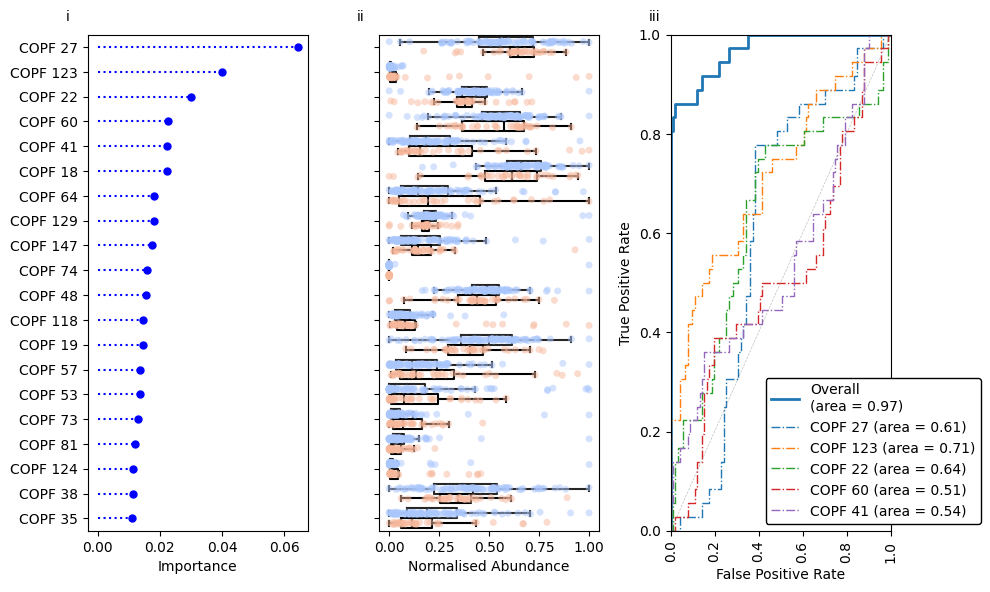

In [27]:
# run the GBRF

intcol = 'CS_Pseudomonas aeruginosa'

intcol_title = ""
merged_df = pc_df.join(metadata[[intcol]]).dropna(subset=intcol)

categorical_data, custom_labels = cf_analysis_lib.create_custom_labels(metadata, intcol, merged_df)

X = merged_df.drop(intcol, axis=1)
y = merged_df[intcol]

if categorical_data:
  model, mse, feature_importances_sorted = cf_analysis_lib.gb_classifier_model(X, y, n_estimators=1000, n_iter_no_change=20)
  met = 'classifier'
else:
  model, mse, feature_importances_sorted = cf_analysis_lib.gb_regressor_model(X, y)
  met = 'regressor'

print(f"We used {model.n_estimators_} estimators for the random forest {met}", file=sys.stderr)
print(f"Mean squared error for {intcol} using {met} is {mse}", file=sys.stderr)
fig, axes = cf_analysis_lib.plot_importance_abundance_roc(merged_df, feature_importances_sorted, intcol, intcol_title, model,
                                     custom_labels, plot_legend=False)

labels = [cf_analysis_lib.int2roman(i+1) for i in range(3)] # this makes the labels roman numerals
for ax, label in zip(axes, labels):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
            fontsize=10, va='top', ha='left')
    ax.set_title("")
print()

plt.tight_layout()
plt.show()

In [32]:
cluster_assignments[cluster_assignments['COPF']==27]

,Feature,COPF,Cluster
305,Glycerolipid and Glycerophospholipid Metabolis...,27,27
759,"tRNA aminoacylation, Pro",27,27
165,Copper homeostasis: copper tolerance,27,27
585,"Riboflavin, FMN and FAD biosynthesis in Archaea",27,27


In [33]:
cluster_assignments[cluster_assignments['COPF']==123]

,Feature,COPF,Cluster
27,Acyclic terpene utilization,123,123
32,Adenylylsulfate reductase,123,123
1476,Geothermobacteraceae,123,123
15,ABC-type iron transport system,123,123
525,Potential DNA repair cluster,123,123
560,Quorum sensing regulation in Pseudomonas,123,123
109,CMP-pseudaminic acid synthesis,123,123
178,Cytochrome c oxidase EC 1.9.3.1,123,123
223,Dihydropyrimidine dehydrogenase,123,123
135,Cholera toxin,123,123


In [34]:
cluster_assignments[cluster_assignments['COPF']==22]

,Feature,COPF,Cluster
758,"tRNA aminoacylation, Phe",22,22
273,Folate biosynthesis cluster,22,22
205,"DNA repair, bacterial RecBCD pathway",22,22


In [35]:
cluster_assignments[cluster_assignments['COPF']==60]

,Feature,COPF,Cluster
309,Glycogen metabolism,60,60
592,Ribosomal protein S5p acylation,60,60
123,Cell division related cluster including coaD,60,60
714,Type IV pilus,60,60
